# Disease Prediction Model - Model Selection and Training

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

### 1.1 Loading transformed datasets

In [2]:
root = Path().resolve().parent

diabetes_path = root / "data" / "processed" / "diabetes_transformed.csv"
df_diabetes = pd.read_csv(diabetes_path)

hypertension_path = root / "data" / "processed" / "hypertension_transformed.csv"
df_hypertension = pd.read_csv(hypertension_path)

heart_path = root / "data" / "processed" / "heart_disease_transformed.csv"
df_heart = pd.read_csv(heart_path)

### 1.2 Loading scalers and encoders

In [3]:
diabetes_scaler_path = root / "models" / "preprocessors" / "scalers" / "diabetes_scaler.pkl"
diabetes_scaler = joblib.load(diabetes_scaler_path)

hypertension_scaler_path = root / "models" / "preprocessors" / "scalers" / "hypertension_scaler.pkl"
hypertension_scaler = joblib.load(hypertension_scaler_path)

heart_scaler_path = root / "models" / "preprocessors" / "scalers" / "heart_scaler.pkl"
heart_scaler = joblib.load(heart_scaler_path)

metabolic_index_scaler_path = root / "models" / "preprocessors" / "scalers" / "metabolic_index_scaler.pkl"
metabolic_index_scaler = joblib.load(metabolic_index_scaler_path)

metabolic_syndrome_scaler_path = root / "models" / "preprocessors" / "scalers" / "metabolic_syndrome_scaler.pkl"
metabolic_syndrome_scaler = joblib.load(metabolic_syndrome_scaler_path);

In [4]:
diabetes_gender_encoder_path = root / "models" / "preprocessors" / "encoders" / "diabetes_gender_encoder.pkl"
diabetes_gender_encoder = joblib.load(diabetes_gender_encoder_path)

diabetes_smoking_encoder_path = root / "models" / "preprocessors" / "encoders" / "diabetes_smoking_encoder.pkl"
diabetes_smoking_encoder = joblib.load(diabetes_smoking_encoder_path)

hypertension_encoders_path = root / "models" / "preprocessors" / "encoders" / "hypertension_encoders.pkl"
hypertension_encoders = joblib.load(hypertension_encoders_path)

heart_gender_encoder_path = root / "models" / "preprocessors" / "encoders" / "heart_gender_encoder.pkl"
heart_gender_encoder = joblib.load(heart_gender_encoder_path)

### 1.3 Helper functions

Helper function to directly display the confusion matrix metrics from a model's test results

In [5]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "precision": tp/(tp+fp),
        "recall": tp/(tp+fn),
        "sensitivity": tp/(tp+fn),
        "specificity": tn/(tn+fp)
    }

## 2. Diabetes Model

### 2.1 Analyzing the dataset

In [6]:
df_diabetes.head()

,age,bmi,hba1c_level,blood_glucose_level,metabolic_index,gender,smoking_history,diabetes
0,1.365999,-0.462589,1.055750,0.637258,0.410140,0,2,1
1,0.580004,-0.281327,0.273000,-0.097820,-0.035382,0,2,0
2,-0.390931,-0.256610,0.351275,-0.325344,-0.076893,0,2,0
3,-0.714576,-0.281327,-0.901126,-1.112927,-0.765127,0,2,0
4,-0.853281,-0.281327,-1.292501,-1.287946,-0.953925,1,2,0


In [7]:
FEATURE_COLS = [x for x in df_diabetes.columns if x != "diabetes"]
TARGET_COL = "diabetes"
print(FEATURE_COLS)

['age', 'bmi', 'hba1c_level', 'blood_glucose_level', 'metabolic_index', 'gender', 'smoking_history']


### 2.2 Train-Test Split

We will go with a 80/20 train-test split

In [8]:
X = df_diabetes[FEATURE_COLS]
y = df_diabetes[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print(f"\nTarget distribution in training set:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test set:\n{y_test.value_counts(normalize=True).round(3)}")

Training set size : 8000
Test set size     : 2000

Target distribution in training set:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64

Target distribution in test set:
diabetes
0    0.5
1    0.5
Name: proportion, dtype: float64


Stratified split ensures that both sets get the same distribution of classes, i.e. the ratio of classes is same in both sets.

### 2.3 Model Training and Selection

We will try three classifiers:
* Logistic Regression
* Random Forest
* Gradient Boosting

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:25s}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV ROC-AUC: 0.9608 ± 0.0044
Random Forest              CV ROC-AUC: 0.9727 ± 0.0040
Gradient Boosting          CV ROC-AUC: 0.9774 ± 0.0030


Now we can evaluate all models using 5-fold stratified cross-validation before final evalutation.

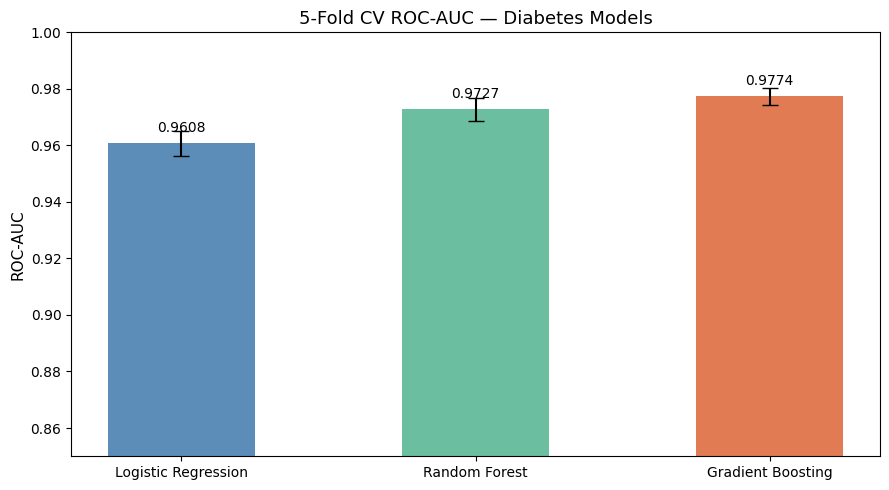

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ["#5B8DB8", "#6BBFA0", "#E07B54"]

bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, width=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title("5-Fold CV ROC-AUC — Diabetes Models", fontsize=13)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_cv_comparison.png", dpi=120)
plt.show()

### 2.4 Final Model Evaluation

Based on the cross-validation results, we can now select the best performing model to train fully and evaluate on the test set.

In [11]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_name]

print(f"Selected model: {best_name}")

best_model.fit(X_train, y_train)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Set Results — {best_name}")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")

Selected model: Gradient Boosting

Test Set Results — Gradient Boosting
  Accuracy : 0.9175
  F1 Score : 0.9182
  ROC-AUC  : 0.9798


### 2.5 Visualizing Performance

#### 2.5.1 Confusion Matrix

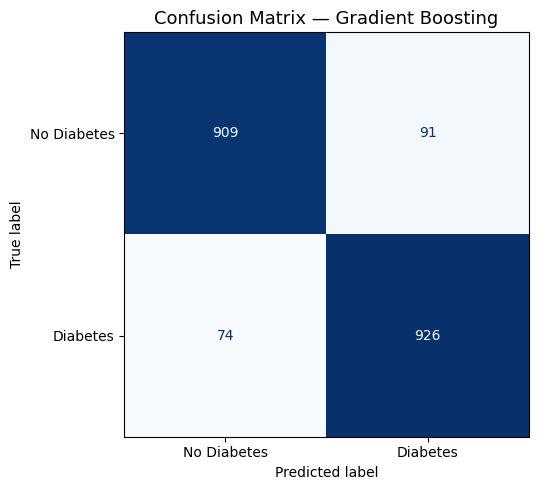

Precision :  91.05
Recall :  92.6
Sensitivity :  92.6
Specificity :  90.9


In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_confusion_matrix.png", dpi=120)
plt.show()

metrics = get_metrics(y_test, y_pred)
for m in metrics:
    print(m.title(), ": ", round(metrics[m]*100, 2))

From the above confusion matrix, we can infer that the model has a good amount of **true predictions**.
However about 3.7% of false negatives are present, which could be a problem as in real-world healthcare settings we would rather get a false positive than a false negative. So, in order to achieve this we will choose to sacrifice some accuracy in order to get lesser number of false negatives.

In [13]:
THRESHOLD = 0.3
y_pred_prob = best_model.predict_proba(X_test)[:, 1]
y_pred      = (y_pred_prob >= THRESHOLD).astype(int)


acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Set Results — {best_name}")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")


Test Set Results — Gradient Boosting
  Accuracy : 0.9070
  F1 Score : 0.9123
  ROC-AUC  : 0.9798


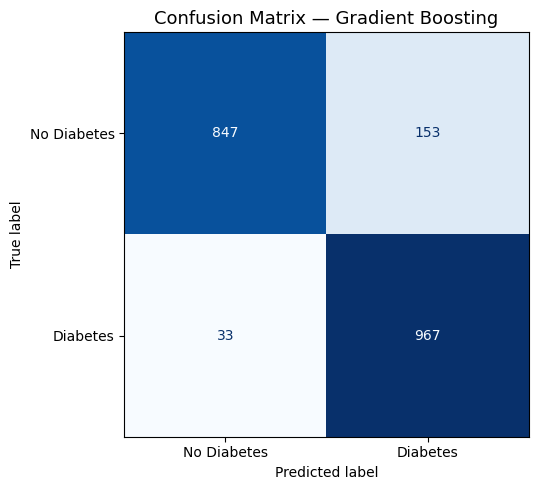

Precision :  86.34
Recall :  96.7
Sensitivity :  96.7
Specificity :  84.7


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_confusion_matrix.png", dpi=120)
plt.show()

metrics = get_metrics(y_test, y_pred)
for m in metrics:
    print(m.title(), ": ", round(metrics[m]*100, 2))

#### 2.5.2 ROC Curve

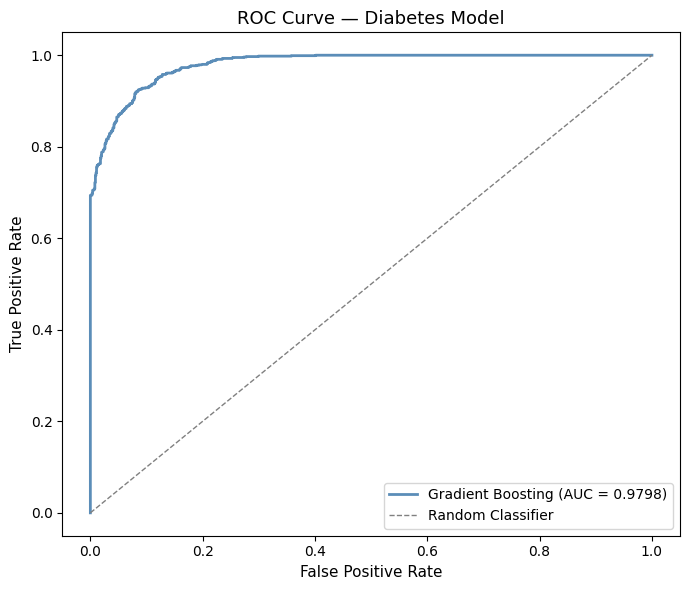

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

ax.plot(fpr, tpr, color="#5B8DB8", lw=2, label=f"{best_name} (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random Classifier")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Diabetes Model", fontsize=13)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_roc_curve.png", dpi=120)
plt.show()

#### 2.5.3 Feature Importance

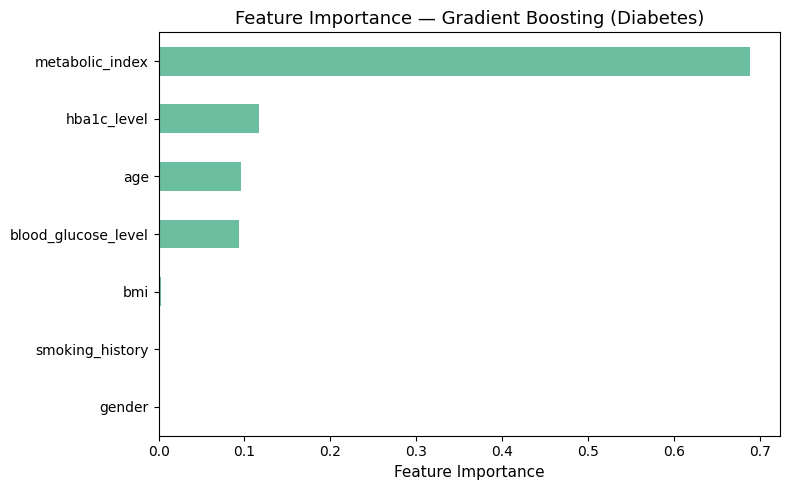

In [16]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    importance_label = "Feature Importance"
else:
    importances = np.abs(best_model.coef_[0])
    importance_label = "Absolute Coefficient"

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind="barh", ax=ax, color="#6BBFA0")

ax.set_xlabel(importance_label, fontsize=11)
ax.set_title(f"Feature Importance — {best_name} (Diabetes)", fontsize=13)

plt.tight_layout()
plt.savefig(root / "plots" / "diabetes_feature_importance.png", dpi=120)
plt.show()

As expected, the engineered feature **metabolic_index** dominates the model, and other important features like **age** and **blood_glucose_level** also contribute quite a bit. Interestingly however, the model relies very less on the **bmi** feature which seems counterintuitive, but this is most likely due to the metabolic index feature being derived from the BMI feature hence BMI actually doesn't give any new information to the model.

## 7. Saving the Model

In [20]:
diabetes_model_path = root / "models" / "trained" / "diabetes_model.pkl"
joblib.dump(best_model, diabetes_model_path)
print(f"Saved: {diabetes_model_path}")

Saved: /home/anush/Documents/GitHub/DSProject2/models/trained/diabetes_model.pkl
